In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("SkyCity Auckland Restaurants & Bars.csv")

In [4]:
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,8662.09,...,3.25,458.25,3682.14,1352.45,752.78,2177.19,0.42,0.45,0.25,0.3
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,10476.55,...,4.72,1600.08,3605.72,1318.61,731.99,3119.38,0.23,0.45,0.25,0.3
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,20975.72,...,3.25,1163.50,7810.95,1555.90,863.42,4172.99,0.44,0.45,0.25,0.3
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,7836.48,...,0.89,231.40,2546.02,-72.25,-40.20,2833.26,0.25,0.45,0.25,0.3
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,8962.74,...,2.66,774.06,3093.09,226.17,125.53,2674.56,0.27,0.45,0.25,0.3


In [5]:
df.shape

(1696, 30)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CuisineType            1696 non-null   object 
 1   RestaurantID           1696 non-null   int64  
 2   RestaurantName         1696 non-null   object 
 3   Segment                1696 non-null   object 
 4   Subregion              1696 non-null   object 
 5   GrowthFactor           1696 non-null   float64
 6   AOV                    1696 non-null   float64
 7   MonthlyOrders          1696 non-null   int64  
 8   InStoreOrders          1696 non-null   int64  
 9   InStoreRevenue         1696 non-null   float64
 10  UberEatsOrders         1696 non-null   int64  
 11  DoorDashOrders         1696 non-null   int64  
 12  SelfDeliveryOrders     1696 non-null   int64  
 13  UberEatsRevenue        1696 non-null   float64
 14  DoorDashRevenue        1696 non-null   float64
 15  Self

In [7]:
df.isnull().sum()

,0
CuisineType,0
RestaurantID,0
RestaurantName,0
Segment,0
Subregion,0
GrowthFactor,0
AOV,0
MonthlyOrders,0
InStoreOrders,0
InStoreRevenue,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['RestaurantID'].duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

,0
CuisineType,object
RestaurantID,int64
RestaurantName,object
Segment,object
Subregion,object
GrowthFactor,float64
AOV,float64
MonthlyOrders,int64
InStoreOrders,int64
InStoreRevenue,float64


In [11]:
df['CalculatedMonthlyOrders'] = (
    df['InStoreOrders'] +
    df['UberEatsOrders'] +
    df['DoorDashOrders'] +
    df['SelfDeliveryOrders']
)

df['OrderMismatch'] = df['MonthlyOrders'] - df['CalculatedMonthlyOrders']

df['OrderMismatch'].value_counts()

,count
OrderMismatch,
0,1696


In [13]:
df['CalcInStoreRevenue'] = df['InStoreOrders'] * df['AOV']
df['InStoreRevenueDiff'] = df['InStoreRevenue'] - df['CalcInStoreRevenue']

df[['InStoreRevenue', 'CalcInStoreRevenue', 'InStoreRevenueDiff']].head()

,InStoreRevenue,CalcInStoreRevenue,InStoreRevenueDiff
0,8662.09,8662.09,0.000000e+00
1,10476.55,10476.55,-1.818989e-12
2,20975.72,20975.72,0.000000e+00
3,7836.48,7836.48,-9.094947e-13
4,8962.74,8962.74,-1.818989e-12


In [15]:
df['CalcUberEatsRevenue'] = df['UberEatsOrders'] * df['AOV']
df['CalcDoorDashRevenue'] = df['DoorDashOrders'] * df['AOV']
df['CalcSelfDeliveryRevenue'] = df['SelfDeliveryOrders'] * df['AOV']

df['UberEatsRevenueDiff'] = df['UberEatsRevenue'] - df['CalcUberEatsRevenue']
df['DoorDashRevenueDiff'] = df['DoorDashRevenue'] - df['CalcDoorDashRevenue']
df['SelfDeliveryRevenueDiff'] = df['SelfDeliveryRevenue'] - df['CalcSelfDeliveryRevenue']

In [16]:
df['CalcInStoreShare'] = df['InStoreOrders'] / df['MonthlyOrders']
df['CalcUE_share'] = df['UberEatsOrders'] / (df['UberEatsOrders'] + df['DoorDashOrders'] + df['SelfDeliveryOrders'])
df['CalcDD_share'] = df['DoorDashOrders'] / (df['UberEatsOrders'] + df['DoorDashOrders'] + df['SelfDeliveryOrders'])
df['CalcSD_share'] = df['SelfDeliveryOrders'] / (df['UberEatsOrders'] + df['DoorDashOrders'] + df['SelfDeliveryOrders'])

In [17]:
df[['InStoreShare', 'CalcInStoreShare', 'UE_share', 'CalcUE_share', 'DD_share', 'CalcDD_share', 'SD_share', 'CalcSD_share']].head()

,InStoreShare,CalcInStoreShare,UE_share,CalcUE_share,DD_share,CalcDD_share,SD_share,CalcSD_share
0,0.42,0.294910,0.45,0.450106,0.25,0.250531,0.3,0.299363
1,0.23,0.186599,0.45,0.449956,0.25,0.249779,0.3,0.300266
2,0.44,0.305183,0.45,0.450126,0.25,0.249790,0.3,0.300084
3,0.25,0.199446,0.45,0.449827,0.25,0.250288,0.3,0.299885
4,0.27,0.212195,0.45,0.449948,0.25,0.249742,0.3,0.300310


In [18]:
df['Final_InStoreShare'] = (
    df['InStoreOrders'] / df['MonthlyOrders']
)

df['Final_UE_share'] = (
    df['UberEatsOrders'] / df['MonthlyOrders']
)

df['Final_DD_share'] = (
    df['DoorDashOrders'] / df['MonthlyOrders']
)

df['Final_SD_share'] = (
    df['SelfDeliveryOrders'] / df['MonthlyOrders']
)

In [19]:
df['FinalShareSum'] = (
    df['Final_InStoreShare'] +
    df['Final_UE_share'] +
    df['Final_DD_share'] +
    df['Final_SD_share']
)

df['FinalShareSum'].describe()

,FinalShareSum
count,1.696000e+03
mean,1.000000e+00
std,4.125089e-17
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


In [20]:
df['DeliveryShareSum'] = df['UE_share'] + df['DD_share'] + df['SD_share']

df['DeliveryShareSum'].describe()

,DeliveryShareSum
count,1696.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [22]:
numeric_cols = df.select_dtypes(include=np.number).columns

negative_values = (df[numeric_cols] < 0).sum()
negative_values[negative_values > 0]

,0
UberEatsNetProfit,538
DoorDashNetProfit,538
SelfDeliveryNetProfit,90
InStoreRevenueDiff,273
UberEatsRevenueDiff,255
DoorDashRevenueDiff,275
SelfDeliveryRevenueDiff,258


In [23]:
df[['MonthlyOrders', 'AOV', 'InStoreRevenue', 'UberEatsRevenue',
    'DoorDashRevenue', 'SelfDeliveryRevenue']].describe()

,MonthlyOrders,AOV,InStoreRevenue,UberEatsRevenue,DoorDashRevenue,SelfDeliveryRevenue
count,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000
mean,1190.527123,38.516887,8422.392730,18170.030360,9899.399145,9345.033190
std,422.334848,4.459408,5851.233352,6959.241673,3750.087557,5191.322908
min,441.000000,29.790000,412.360000,5050.950000,2876.700000,1897.200000
25%,827.000000,34.787500,3904.342500,12524.745000,6806.920000,5631.852500
50%,1182.000000,38.340000,6791.430000,17548.980000,9564.800000,8066.460000
75%,1525.000000,42.495000,11550.755000,23016.000000,12617.602500,11852.907500
max,2337.000000,47.230000,35356.230000,43038.960000,21313.440000,32481.540000


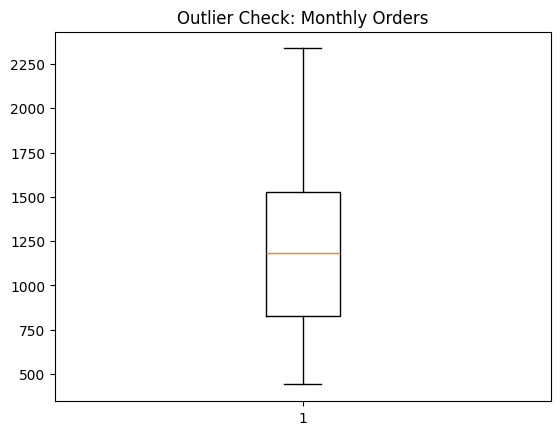

In [24]:
import matplotlib.pyplot as plt

plt.boxplot(df['MonthlyOrders'])
plt.title("Outlier Check: Monthly Orders")
plt.show()

In [25]:
df['TotalDeliveryOrders'] = (
    df['UberEatsOrders'] +
    df['DoorDashOrders'] +
    df['SelfDeliveryOrders']
)

df['TotalRevenue'] = (
    df['InStoreRevenue'] +
    df['UberEatsRevenue'] +
    df['DoorDashRevenue'] +
    df['SelfDeliveryRevenue']
)

df['TotalNetProfit'] = (
    df['InStoreNetProfit'] +
    df['UberEatsNetProfit'] +
    df['DoorDashNetProfit'] +
    df['SelfDeliveryNetProfit']
)

df['AggregatorOrders'] = (
    df['UberEatsOrders'] +
    df['DoorDashOrders']
)

df['AggregatorDependence'] = df['AggregatorOrders'] / df['MonthlyOrders']

df['InStoreReliance'] = df['InStoreOrders'] / df['MonthlyOrders']

In [26]:
def risk_category(value):
    if value >= 0.70:
        return "High Risk"
    elif value >= 0.50:
        return "Medium Risk"
    else:
        return "Low Risk"

df['AggregatorRiskCategory'] = df['AggregatorDependence'].apply(risk_category)

In [27]:
df['AggregatorRiskCategory'].value_counts()

,count
AggregatorRiskCategory,
Medium Risk,810
High Risk,603
Low Risk,283


In [28]:
df.to_csv("cleaned_skycity_data.csv", index=False)

In [29]:
temp_cols = [
    'CalculatedMonthlyOrders',
    'OrderMismatch',

    'CalcInStoreRevenue',
    'CalcUberEatsRevenue',
    'CalcDoorDashRevenue',
    'CalcSelfDeliveryRevenue',

    'InStoreRevenueDiff',
    'UberEatsRevenueDiff',
    'DoorDashRevenueDiff',
    'SelfDeliveryRevenueDiff',

    'CalcInStoreShare',
    'CalcUE_share',
    'CalcDD_share',
    'CalcSD_share',

    'FinalShareSum',
    'DeliveryShareSum'
]

df.drop(columns=temp_cols, inplace=True)

In [30]:
df.to_csv("final_cleaned_skycity_data.csv", index=False)